# Shock Cord Load and Factor of Safety

This notebook estimates the force during **main parachute deployment** and compares it against the rated strength of **1/4 in Amsteel Blue** to compute factor of safety.

Force model used:
- Average deployment tension: $F = m\left(\frac{|\Delta v|}{\Delta t} + g\right)$
- Additional max deployment tension calculated using $F = m * a_{\max}$
- Factor of safety: $FoS = \frac{Strength}{Load}$


In [9]:
# Inputs (edit these for your flight)
mass_lbm = 35  # Rocket mass at main deployment, lbm
v_before_main_fts = 172.2  # Descent speed before main deployment, ft/s
v_after_main_fts = 14.9  # Descent speed after inflation/stabilization, ft/s
deployment_time_s = 0.40  # Time over which velocity change occurs, seconds
max_g_main = 50.8  # Maximum expected deceleration in g's (measured main channel max accel)
required_fos = 3.0
knot_efficiency = 0.50  # Conservative retained strength fraction for a knotted termination
dynamic_shock_factor=1.0 / 3.0  # Conservative additional factor to account for dynamic shock loading beyond the simple impulse calculation

# Amsteel Blue minimum break strengths by diameter (typical published values)
amsteel_strength_lbf_quart = 8600.0   # 1/4 in
amsteel_strength_lbf_quint = 12300.0  # 5/16 in
amsteel_strength_lbf_oct   = 17600.0  # 3/8 in

# Constants
KG_PER_LBM = 0.45359237
M_PER_FT = 0.3048
N_PER_LBF = 4.4482216152605
g = 9.80665

# Derived inputs (convert to SI units for calculations)
mass_kg = mass_lbm * KG_PER_LBM
v_before_main_mps = v_before_main_fts * M_PER_FT
v_after_main_mps = v_after_main_fts * M_PER_FT

# Strength cases for all three diameters × three treatment scenarios
# Used by the FoS table and the grouped bar chart
diameters_main = {
    '1/4"': amsteel_strength_lbf_quart,
    '5/16"': amsteel_strength_lbf_quint,
    '3/8"': amsteel_strength_lbf_oct,
}
treatments_main = {
    'Static': 1.0,
    'Dynamic (~1/3)': dynamic_shock_factor,
    'Dynamic + Knot (~1/6)': dynamic_shock_factor * knot_efficiency,
}

strength_lbf = {
    f'{diam} {treatment}': base * factor
    for diam, base in diameters_main.items()
    for treatment, factor in treatments_main.items()
}

In [10]:
# Calculations
delta_v = abs(v_before_main_mps - v_after_main_mps)
a_mag = delta_v / deployment_time_s
a_mag_g = a_mag / g

avg_tension_N = mass_kg * (a_mag + g)
peak_tension_N = mass_kg * max_g_main * g

loads_N = {
    "Average deployment load": avg_tension_N,
    f"Peak load at {max_g_main:.0f} g": peak_tension_N,
}
loads_lbf = {name: value / N_PER_LBF for name, value in loads_N.items()}

fos = {
    strength_name: {
        load_name: strength_value / load_value
        for load_name, load_value in loads_lbf.items()
    }
    for strength_name, strength_value in strength_lbf.items()
}

print(f"Estimated deceleration magnitude: {a_mag:.2f} m/s^2 ({a_mag_g:.2f} g)")
print(f"Delta-V across main deployment: {delta_v:.2f} m/s ({delta_v / M_PER_FT:.1f} ft/s)")
print()
print("Load cases:")
for name, load_value in loads_lbf.items():
    print(f"- {name}: {load_value:,.1f} lbf ({load_value * N_PER_LBF:,.0f} N)")
print()
print("Strength cases:")
for name, strength_value in strength_lbf.items():
    print(f"- {name}: {strength_value:,.0f} lbf ({strength_value * N_PER_LBF:,.0f} N)")

Estimated deceleration magnitude: 119.86 m/s^2 (12.22 g)
Delta-V across main deployment: 47.95 m/s (157.3 ft/s)

Load cases:
- Average deployment load: 462.8 lbf (2,059 N)
- Peak load at 51 g: 1,778.0 lbf (7,909 N)

Strength cases:
- 1/4" Static: 8,600 lbf (38,255 N)
- 1/4" Dynamic (~1/3): 2,867 lbf (12,752 N)
- 1/4" Dynamic + Knot (~1/6): 1,433 lbf (6,376 N)
- 5/16" Static: 12,300 lbf (54,713 N)
- 5/16" Dynamic (~1/3): 4,100 lbf (18,238 N)
- 5/16" Dynamic + Knot (~1/6): 2,050 lbf (9,119 N)
- 3/8" Static: 17,600 lbf (78,289 N)
- 3/8" Dynamic (~1/3): 5,867 lbf (26,096 N)
- 3/8" Dynamic + Knot (~1/6): 2,933 lbf (13,048 N)


In [11]:
# Factor-of-safety summary and design check
import pandas as pd

design_strength_case = '1/4" Dynamic + Knot (~1/6)'
design_load_case = f"Peak load at {max_g_main:.0f} g"

rows = []
for strength_name, row in fos.items():
    for load_name, value in row.items():
        rows.append(
            {
                "Strength case": strength_name,
                "Load case": load_name,
                "FoS": round(value, 2),
                "Target FoS": required_fos,
                "Meets target": "PASS" if value >= required_fos else "CHECK",
            }
        )

fos_table = pd.DataFrame(rows)
fos_table["Design case"] = (
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
).map({True: "<- selected", False: ""})

design_row = fos_table.loc[
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
].iloc[0]
design_fos = float(design_row["FoS"])

display(fos_table)

print()
if design_fos >= required_fos:
    print(
        f"PASS: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, meeting target >= {required_fos:.1f}"
    )
else:
    print(
        f"CHECK DESIGN: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, below target >= {required_fos:.1f}"
    )

,Strength case,Load case,FoS,Target FoS,Meets target,Design case
0,"1/4"" Static",Average deployment load,18.58,3.0,PASS,
1,"1/4"" Static",Peak load at 51 g,4.84,3.0,PASS,
2,"1/4"" Dynamic (~1/3)",Average deployment load,6.19,3.0,PASS,
3,"1/4"" Dynamic (~1/3)",Peak load at 51 g,1.61,3.0,CHECK,
4,"1/4"" Dynamic + Knot (~1/6)",Average deployment load,3.10,3.0,PASS,
5,"1/4"" Dynamic + Knot (~1/6)",Peak load at 51 g,0.81,3.0,CHECK,<- selected
6,"5/16"" Static",Average deployment load,26.58,3.0,PASS,
7,"5/16"" Static",Peak load at 51 g,6.92,3.0,PASS,
8,"5/16"" Dynamic (~1/3)",Average deployment load,8.86,3.0,PASS,
9,"5/16"" Dynamic (~1/3)",Peak load at 51 g,2.31,3.0,CHECK,



CHECK DESIGN: 1/4" Dynamic + Knot (~1/6) vs Peak load at 51 g gives FoS = 0.81, below target >= 3.0


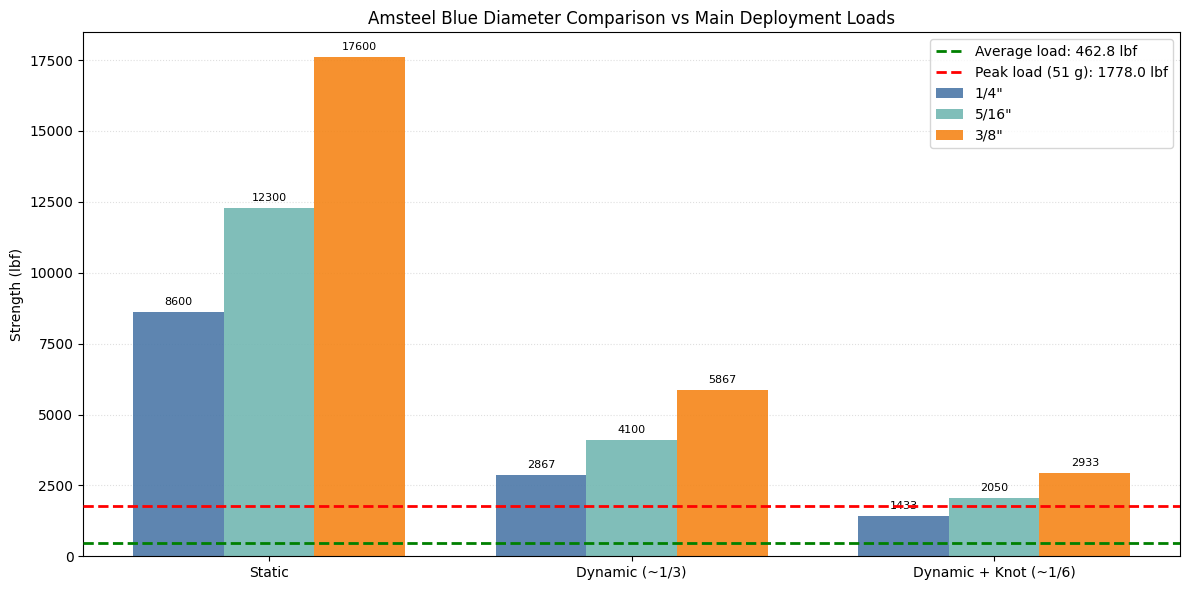

In [12]:
import matplotlib.pyplot as plt
import numpy as np

treatment_labels = list(treatments_main.keys())
diameter_labels = list(diameters_main.keys())
colors = ["#4c78a8", "#72b7b2", "#f58518"]

x = np.arange(len(treatment_labels))
n_diam = len(diameter_labels)
width = 0.25
offsets = np.linspace(-(n_diam - 1) / 2, (n_diam - 1) / 2, n_diam) * width

avg_load_lbf = loads_lbf["Average deployment load"]
peak_load_lbf = loads_lbf[f"Peak load at {max_g_main:.0f} g"]
label_offset = max(strength_lbf.values()) * 0.01

fig, ax = plt.subplots(figsize=(12, 6))

for i, (diam_label, base_strength) in enumerate(diameters_main.items()):
    vals = [base_strength * factor for factor in treatments_main.values()]
    rects = ax.bar(
        x + offsets[i],
        vals,
        width,
        label=diam_label,
        color=colors[i],
        alpha=0.9,
        zorder=2,
    )
    for rect, v in zip(rects, vals):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            v + label_offset,
            f"{v:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.axhline(
    avg_load_lbf,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Average load: {avg_load_lbf:.1f} lbf",
    zorder=3,
)
ax.axhline(
    peak_load_lbf,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Peak load ({max_g_main:.0f} g): {peak_load_lbf:.1f} lbf",
    zorder=3,
)

ax.set_xticks(x)
ax.set_xticklabels(treatment_labels)
ax.set_ylabel("Strength (lbf)")
ax.set_title("Amsteel Blue Diameter Comparison vs Main Deployment Loads")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.legend()
plt.tight_layout()
plt.show()

## Notes
- Update inputs with your measured pre-main and post-main descent rates from flight data.
- Deployment time is often the largest uncertainty; run sensitivity checks across plausible values.
- Published line strength can vary by manufacturer and knot/splice method. Use your exact hardware specification when finalizing FoS.


## Drogue Deployment calculations (taking into account horizontal velocities)

In [13]:
# Drogue deployment inputs (edit these for your flight)
mass_lbm_drogue = 35.0  # Rocket mass at drogue deployment, lbm

# Velocity components use a signed convention:
# - vertical: positive downward
# - horizontal: positive along your chosen downrange axis
v_vertical_before_drogue_fts = -15.1
v_vertical_after_drogue_fts = 117.0
v_horizontal_before_drogue_fts = 135.9
v_horizontal_after_drogue_fts = 25.0

deployment_time_drogue_s = 34
max_g_drogue = 18.6
required_fos_drogue = 3.0
knot_efficiency_drogue = 0.50

# 1/4 in Amsteel Blue minimum break strength (typical published value)
amsteel_strength_lbf_drogue = 8600.0

# Constants
KG_PER_LBM_DROGUE = 0.45359237
M_PER_FT_DROGUE = 0.3048
N_PER_LBF_DROGUE = 4.4482216152605
g_drogue = 9.80665

# Derived inputs
mass_kg_drogue = mass_lbm_drogue * KG_PER_LBM_DROGUE
v_vertical_before_drogue_mps = v_vertical_before_drogue_fts * M_PER_FT_DROGUE
v_vertical_after_drogue_mps = v_vertical_after_drogue_fts * M_PER_FT_DROGUE
v_horizontal_before_drogue_mps = v_horizontal_before_drogue_fts * M_PER_FT_DROGUE
v_horizontal_after_drogue_mps = v_horizontal_after_drogue_fts * M_PER_FT_DROGUE

strength_lbf_drogue = {
    "Amsteel Blue (static)": amsteel_strength_lbf_drogue,
    "Amsteel Blue (dynamic)": amsteel_strength_lbf_drogue / 3.0,
    "Amsteel Blue (dynamic + knot)": (amsteel_strength_lbf_drogue / 3.0) * knot_efficiency_drogue,
}

In [14]:
# Drogue deployment calculations
import math

speed_before_drogue_mps = math.hypot(
    v_horizontal_before_drogue_mps,
    v_vertical_before_drogue_mps,
 )
speed_after_drogue_mps = math.hypot(
    v_horizontal_after_drogue_mps,
    v_vertical_after_drogue_mps,
 )

delta_v_vertical_drogue_mps = v_vertical_after_drogue_mps - v_vertical_before_drogue_mps
delta_v_horizontal_drogue_mps = v_horizontal_after_drogue_mps - v_horizontal_before_drogue_mps
delta_v_total_drogue_mps = math.hypot(
    delta_v_horizontal_drogue_mps,
    delta_v_vertical_drogue_mps,
 )
a_drogue_mps2 = delta_v_total_drogue_mps / deployment_time_drogue_s
a_drogue_g = a_drogue_mps2 / g_drogue

avg_tension_drogue_N = mass_kg_drogue * (a_drogue_mps2 + g_drogue)
peak_tension_drogue_N = mass_kg_drogue * max_g_drogue * g_drogue

loads_drogue_N = {
    "Average drogue deployment load": avg_tension_drogue_N,
    f"Peak load at {max_g_drogue:.0f} g": peak_tension_drogue_N,
}
loads_drogue_lbf = {
    name: value / N_PER_LBF_DROGUE
    for name, value in loads_drogue_N.items()
}

fos_drogue = {
    strength_name: {
        load_name: strength_value / load_value
        for load_name, load_value in loads_drogue_lbf.items()
    }
    for strength_name, strength_value in strength_lbf_drogue.items()
}

print(f"Speed before drogue deployment: {speed_before_drogue_mps:.2f} m/s ({speed_before_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Speed after drogue deployment: {speed_after_drogue_mps:.2f} m/s ({speed_after_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Vector delta-V across drogue deployment: {delta_v_total_drogue_mps:.2f} m/s ({delta_v_total_drogue_mps / M_PER_FT_DROGUE:.1f} ft/s)")
print(f"Average deceleration magnitude: {a_drogue_mps2:.2f} m/s^2 ({a_drogue_g:.2f} g)")
print()
print("Load cases:")
for name, load_value in loads_drogue_lbf.items():
    print(f"- {name}: {load_value:,.1f} lbf ({load_value * N_PER_LBF_DROGUE:,.0f} N)")
print()
print("Strength cases:")
for name, strength_value in strength_lbf_drogue.items():
    print(f"- {name}: {strength_value:,.0f} lbf ({strength_value * N_PER_LBF_DROGUE:,.0f} N)")

Speed before drogue deployment: 41.68 m/s (136.7 ft/s)
Speed after drogue deployment: 36.47 m/s (119.6 ft/s)
Vector delta-V across drogue deployment: 52.57 m/s (172.5 ft/s)
Average deceleration magnitude: 1.55 m/s^2 (0.16 g)

Load cases:
- Average drogue deployment load: 40.5 lbf (180 N)
- Peak load at 19 g: 651.0 lbf (2,896 N)

Strength cases:
- Amsteel Blue (static): 8,600 lbf (38,255 N)
- Amsteel Blue (dynamic): 2,867 lbf (12,752 N)
- Amsteel Blue (dynamic + knot): 1,433 lbf (6,376 N)


In [15]:
# Drogue factor-of-safety summary and design check
import pandas as pd

design_strength_case_drogue = "Amsteel Blue (dynamic + knot)"
design_load_case_drogue = f"Peak load at {max_g_drogue:.0f} g"

rows_drogue = []
for strength_name, row in fos_drogue.items():
    for load_name, value in row.items():
        rows_drogue.append(
            {
                "Strength case": strength_name,
                "Load case": load_name,
                "FoS": round(value, 2),
                "Target FoS": required_fos_drogue,
                "Meets target": "PASS" if value >= required_fos_drogue else "CHECK",
            }
        )

fos_table_drogue = pd.DataFrame(rows_drogue)
fos_table_drogue["Design case"] = (
    (fos_table_drogue["Strength case"] == design_strength_case_drogue)
    & (fos_table_drogue["Load case"] == design_load_case_drogue)
).map({True: "<- selected", False: ""})

design_row_drogue = fos_table_drogue.loc[
    (fos_table_drogue["Strength case"] == design_strength_case_drogue)
    & (fos_table_drogue["Load case"] == design_load_case_drogue)
].iloc[0]
design_fos_drogue = float(design_row_drogue["FoS"])

display(fos_table_drogue)

print()
if design_fos_drogue >= required_fos_drogue:
    print(
        f"PASS: {design_strength_case_drogue} vs {design_load_case_drogue} gives FoS = "
        f"{design_fos_drogue:.2f}, meeting target >= {required_fos_drogue:.1f}"
    )
else:
    print(
        f"CHECK DESIGN: {design_strength_case_drogue} vs {design_load_case_drogue} gives FoS = "
        f"{design_fos_drogue:.2f}, below target >= {required_fos_drogue:.1f}"
    )

,Strength case,Load case,FoS,Target FoS,Meets target,Design case
0,Amsteel Blue (static),Average drogue deployment load,212.25,3.0,PASS,
1,Amsteel Blue (static),Peak load at 19 g,13.21,3.0,PASS,
2,Amsteel Blue (dynamic),Average drogue deployment load,70.75,3.0,PASS,
3,Amsteel Blue (dynamic),Peak load at 19 g,4.40,3.0,PASS,
4,Amsteel Blue (dynamic + knot),Average drogue deployment load,35.37,3.0,PASS,
5,Amsteel Blue (dynamic + knot),Peak load at 19 g,2.20,3.0,CHECK,<- selected



CHECK DESIGN: Amsteel Blue (dynamic + knot) vs Peak load at 19 g gives FoS = 2.20, below target >= 3.0


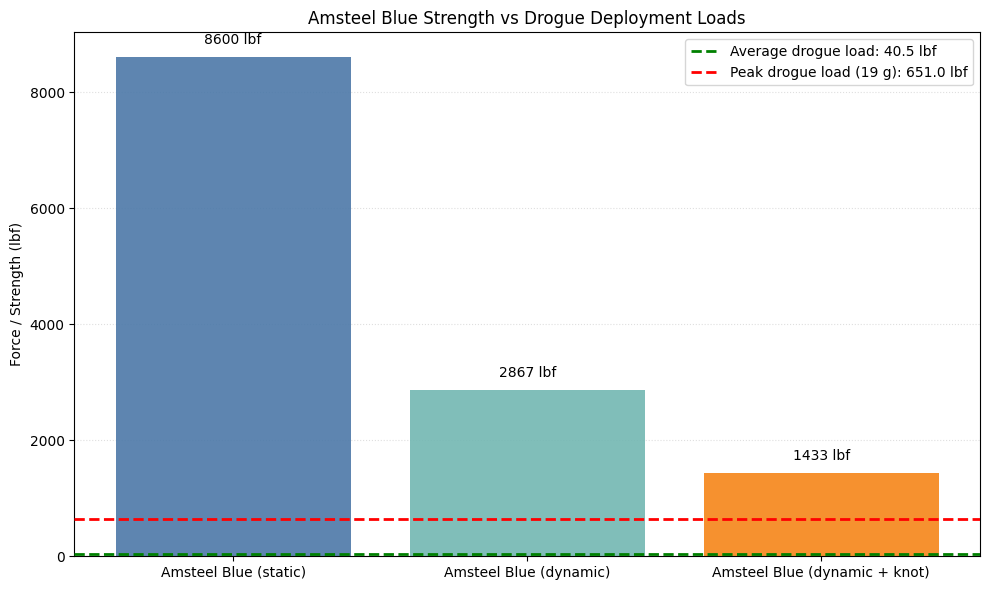

In [16]:
import matplotlib.pyplot as plt

labels_drogue = list(strength_lbf_drogue.keys())
strength_values_drogue = [strength_lbf_drogue[label] for label in labels_drogue]
avg_load_drogue_lbf = loads_drogue_lbf["Average drogue deployment load"]
peak_load_drogue_lbf = loads_drogue_lbf[f"Peak load at {max_g_drogue:.0f} g"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    labels_drogue,
    strength_values_drogue,
    color=["#4c78a8", "#72b7b2", "#f58518"],
    alpha=0.9,
    zorder=2,
 )

ax.axhline(
    avg_load_drogue_lbf,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Average drogue load: {avg_load_drogue_lbf:.1f} lbf",
    zorder=3,
 )
ax.axhline(
    peak_load_drogue_lbf,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Peak drogue load ({max_g_drogue:.0f} g): {peak_load_drogue_lbf:.1f} lbf",
    zorder=3,
 )

label_offset_drogue = max(strength_values_drogue) * 0.02
for bar, value in zip(bars, strength_values_drogue):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + label_offset_drogue,
        f"{value:.0f} lbf",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylabel("Force / Strength (lbf)")
ax.set_title("Amsteel Blue Strength vs Drogue Deployment Loads")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Drogue Notes
- Enter signed velocity components so the vector delta-V includes both vertical and horizontal changes.
- If you only know magnitudes, keep the signs consistent with one chosen axis and direction convention.
- The peak-load case still uses the separate `max_g_drogue` assumption, just like the main-deployment section.